# Gabor Noise - One Parameter at a Time

In the tiling notebook we add *all* parameter noises at once with equal Gaussian
standard deviations. But each parameter moves a *different* aspect of the noise:
spatial layout (`means`), patch size (`scales`), orientation (`rotations`),
grating frequency (`frequencies`), the two stripe colors (`colors`, `colors2`) and
density (`opacities`).

This notebook renders a trained `GaborModel` while perturbing **exactly one
parameter at a time**, sweeping the Gaussian standard deviation so you can see how
each knob changes the texture.

## Pipeline

1. Load a trained `GaborModel` from checkpoint
2. Render the base (unperturbed) tile for reference
3. For each parameter, render a row of tiles with growing noise strength
4. Show the base next to each sweep for direct comparison


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import gabor_noise_renderer as gnr
from gabor_noise_renderer import (
    GaborModel,
    render_gabor_image,
)

torch.manual_seed(42)
np.random.seed(42)

print(f"device: {gnr.device}")


device: cuda


## 1. Configuration

In [2]:
# --- tile rendering ---
TILE_SIZE = 512        # kernel_size for each tile render (must match checkpoint)

# --- how strong the per-parameter noise gets ---
# Each entry is a max Gaussian std for that parameter. We sweep 0 -> this value.
MAX_STD = {
    "means":       0.10,   # NDC units (of [-1,1] range) -> moves patches around
    "scales":      0.35,   # stretch factor -> resizes patches
    "rotations":   0.60,   # radians -> spins patches
    "frequencies": 0.30,   # cycles per unit -> changes the grating pitch
    "colors":      0.30,   # adds random hue/color source terms
    "colors2":     0.30,   # adds random hue/color2 terms
    "opacities":   0.40,   # scalar -> changes patch density/strength
}

# how many samples to render at each noise level
SEED_PER_STD = 3

# noise standard deviations to sweep (multiples of MAX_STD)
STD_MULT = [0.0, 0.2, 1.0]
LABELS = ["0x", "0.2x max", "1x max"]

# --- checkpoint ---
WEIGHTS_PATH = "outputs/2026_09_02-13_09_45/model_weights.pt"


## 2. Load the model

In [3]:
base_model, loaded_kernel_size = GaborModel.load_weights(WEIGHTS_PATH)
assert loaded_kernel_size == TILE_SIZE, (
    f"Checkpoint kernel_size ({loaded_kernel_size}) != TILE_SIZE ({TILE_SIZE})"
)

n_prims = base_model._means.shape[0]
print(f"Loaded {n_prims} primitives")

ALL_PARAMS = ["means", "colors", "colors2", "frequencies",
              "opacities", "scales", "rotations"]

for name in ALL_PARAMS:
    t = getattr(base_model, "_" + name).data
    print(f"  {name:12s} shape={str(tuple(t.shape)):14s} range=[{t.min().item():+.4f}, {t.max().item():+.4f}]")


weights loaded from outputs/2026_09_02-13_09_45/model_weights.pt (500 primitives, kernel_size=512)
Loaded 500 primitives
  means        shape=(500, 2)       range=[-1.9792, +1.6457]
  colors       shape=(500, 3)       range=[-0.5925, +1.5659]
  colors2      shape=(500, 3)       range=[-0.8431, +1.2757]
  frequencies  shape=(500, 2)       range=[-1.5044, +5.8149]
  opacities    shape=(500,)         range=[-0.5917, +1.5469]
  scales       shape=(500, 2)       range=[-0.1707, +6.0947]
  rotations    shape=(500,)         range=[-1.2394, +3.4074]


## 3. Perturb one parameter at a time

`perturb_single` copies the base model unchanged, then adds the same *shared*
Gaussian draw to **only the requested parameter** (scaled by the given std). Every
other parameter stays exactly at its base value, so the row isolates the visual
effect of that one knob.


In [4]:
def perturb_single(base_model, param_name, std, seed):
    """Return a param dict perturbing exactly `param_name` by the same seed.

    Parameters
    ----------
    base_model : GaborModel with ._<param> tensors
    param_name : which of ALL_PARAMS to perturb
    std : float, Gaussian standard deviation to add
    seed : int, deterministic rng seed for the shared draw

    Returns
    -------
    dict of parameter tensors (detached, on device)
    """
    torch.manual_seed(seed)
    params = {}
    for name in ALL_PARAMS:
        base = getattr(base_model, "_" + name).data.clone()
        if name == param_name:
            # one shared draw, scaled by std
            noise = torch.randn_like(base) * std
            params[name] = base + noise
        else:
            params[name] = base  # untouched
    return params


def render_from_params(params, kernel_size, device):
    """Render a Gabor image from a raw parameter dict."""
    return render_gabor_image(
        kernel_size=kernel_size,
        means=params["means"],
        frequencies=params["frequencies"],
        colors=params["colors"],
        colors2=params["colors2"],
        opacities=params["opacities"],
        scales=params["scales"],
        rotations=params["rotations"],
        device=device,
    ).clamp(0, 1).detach().cpu().numpy()


def render_param_sweep(base_model, param_name, max_std, kernel_size, std_mult, seeds):
    """Return list-of-seeds x list-of-std-mults of images for one parameter."""
    grid = []
    for seed in seeds:
        row = []
        for m in std_mult:
            params = perturb_single(base_model, param_name, max_std * m, seed)
            row.append(render_from_params(params, kernel_size, gnr.device))
        grid.append(row)
    return grid

# sanity: perturb `means` alone once and render
test = render_param_sweep(base_model, "means", MAX_STD["means"], TILE_SIZE, [1.0], [1])[0][0]
print("single-param perturbed tile shape:", test.shape)


single-param perturbed tile shape: (512, 512, 3)


## 4. Full sweep - every parameter, one at a time

Each **row** perturbs one parameter. Within the row, the low/med/high columns use
growing standard deviations, and we render several independent seeds at each level
to show the amount of variation a given `std` produces.

The very first column (0x) is the unperturbed base for every row, so differences
from it are purely due to that single parameter.


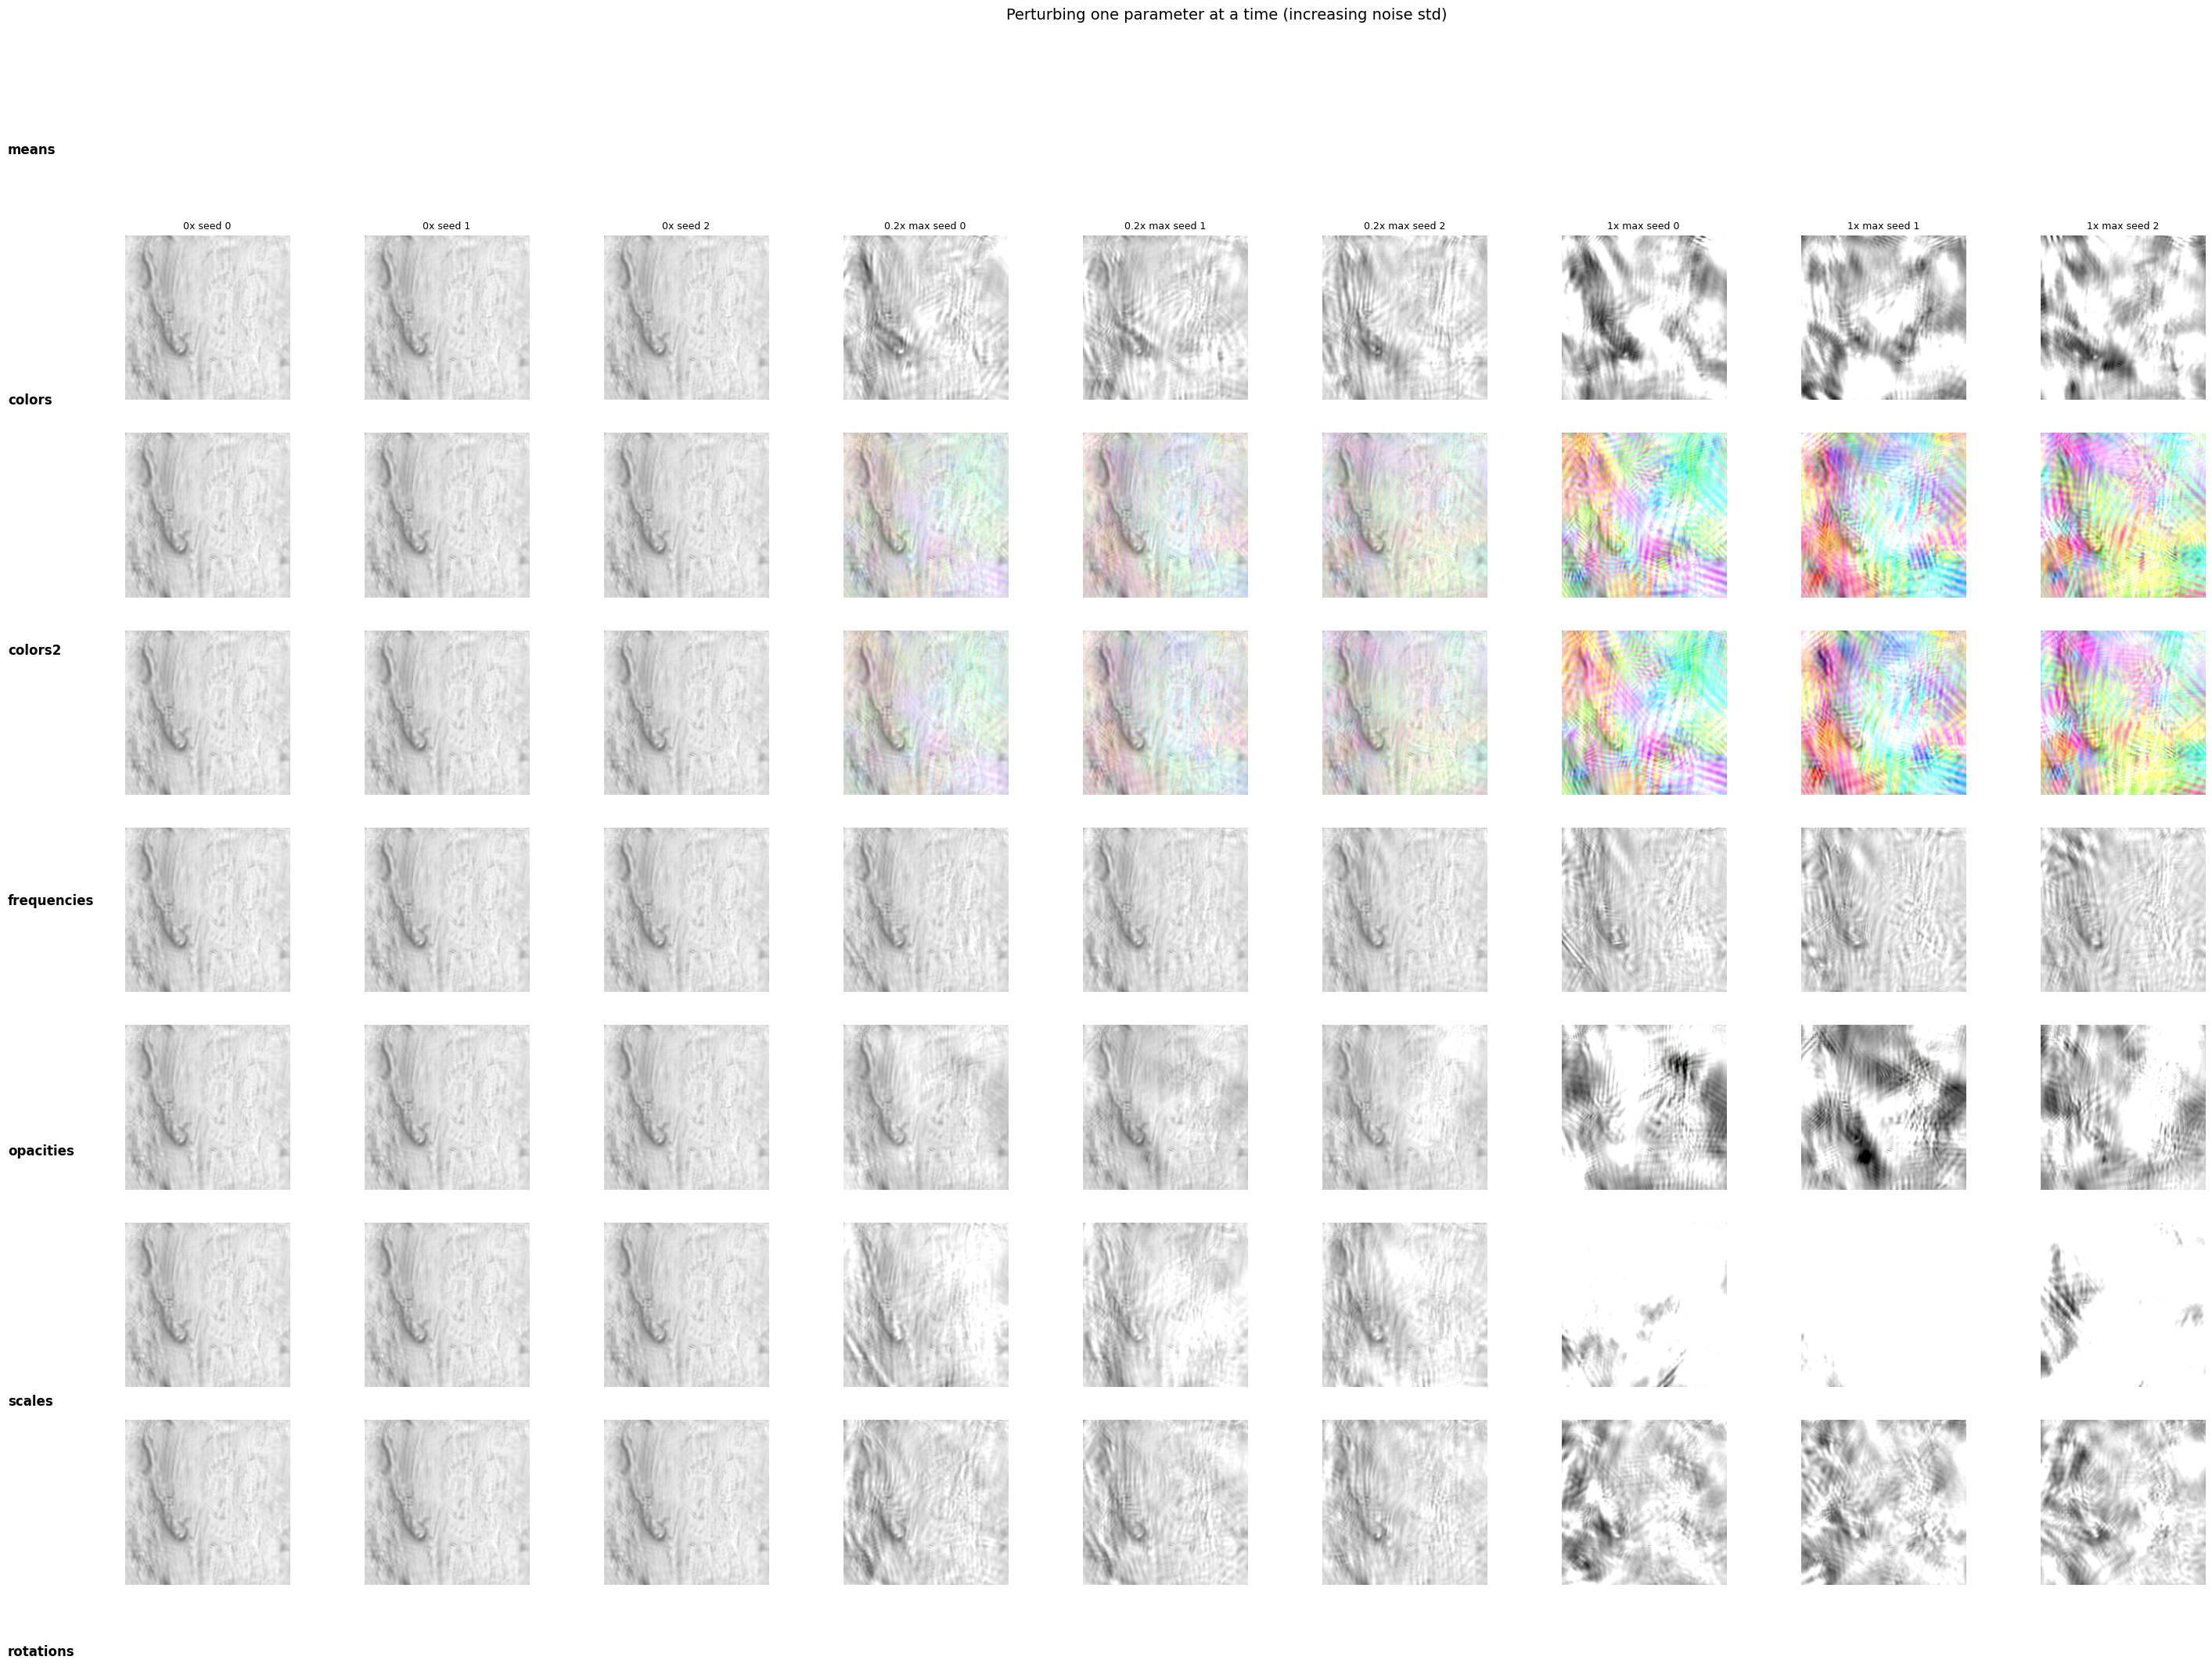

In [5]:
seeds = list(range(SEED_PER_STD))

# render every parameter sweep
sweeps = {}
for param in ALL_PARAMS:
    sweeps[param] = render_param_sweep(
        base_model, param, MAX_STD[param], TILE_SIZE, STD_MULT, seeds,
    )

n_stds = len(STD_MULT)
n_seeds = len(seeds)
fig, axes = plt.subplots(
    len(ALL_PARAMS), n_stds * n_seeds,
    figsize=(3.2 * n_stds * n_seeds + 3.0, 3.2 * len(ALL_PARAMS)),  # +3.0 gutter for labels
    squeeze=False,
)

# draw row labels in the left margin via fig.text (never clipped)
for ri, param in enumerate(ALL_PARAMS):
    y = 1.0 - (ri + 0.5) / len(ALL_PARAMS)
    fig.text(0.01, y, param, va="center", ha="left", fontsize=12, weight="bold",
             transform=fig.transFigure)

for ri, param in enumerate(ALL_PARAMS):
    for si in range(n_stds):
        for seed_i in range(n_seeds):
            ax = axes[ri, si * n_seeds + seed_i]
            ax.imshow(sweeps[param][seed_i][si])
            ax.axis("off")
            if ri == 0:
                ax.set_title(f"{LABELS[si]} seed {seed_i}", fontsize=9)

plt.subplots_adjust(left=0.05)
plt.suptitle("Perturbing one parameter at a time (increasing noise std)", fontsize=14, y=1.01)
plt.show()


## 5. Side by side: base vs. single knob at full strength

Same idea as above but a compact per-parameter row juxtaposing the base tile with
the highest-std render, so the *type* of change each parameter causes is easy to
scan. The title states what visually changes for that knob.


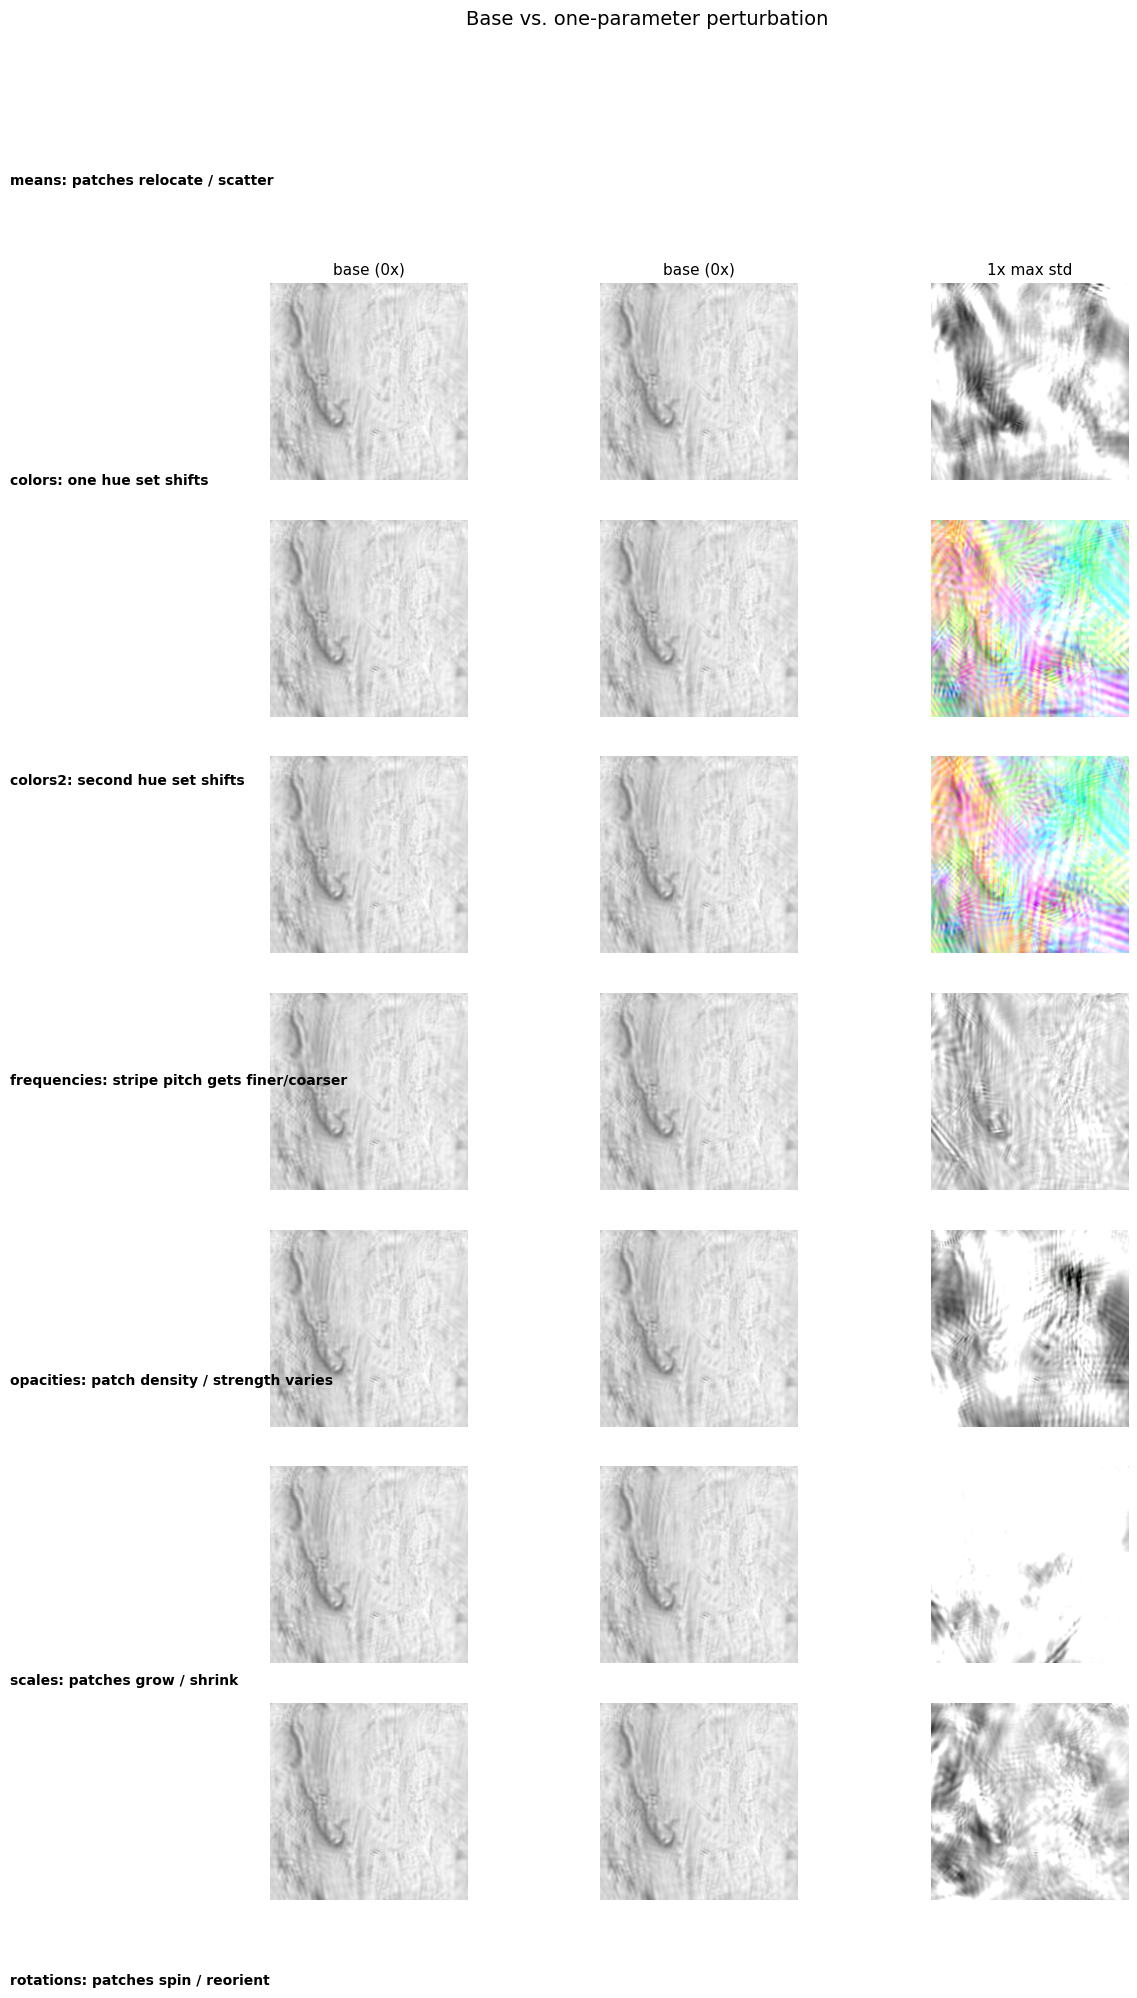

In [6]:
DESCRIPTIONS = {
    "means":       "patches relocate / scatter",
    "scales":      "patches grow / shrink",
    "rotations":   "patches spin / reorient",
    "frequencies": "stripe pitch gets finer/coarser",
    "colors":      "one hue set shifts",
    "colors2":     "second hue set shifts",
    "opacities":   "patch density / strength varies",
}

fig, axes = plt.subplots(len(ALL_PARAMS), 3, figsize=(13.0, 3.0 * len(ALL_PARAMS)), squeeze=False)

# row labels in the left margin via fig.text (never clipped)
for ri, param in enumerate(ALL_PARAMS):
    y = 1.0 - (ri + 0.5) / len(ALL_PARAMS)
    fig.text(0.01, y, f"{param}: {DESCRIPTIONS[param]}", va="center", ha="left",
             fontsize=10, weight="bold", transform=fig.transFigure)

for ri, param in enumerate(ALL_PARAMS):
    base = sweeps[param][0][0]                  # 0x std (same for all)
    full = sweeps[param][0][-1]                 # highest std, seed 0
    axes[ri, 0].imshow(base)
    axes[ri, 0].axis("off")
    if ri == 0:
        axes[ri, 0].set_title("base (0x)", fontsize=11)
    axes[ri, 1].imshow(base)
    axes[ri, 1].axis("off")
    if ri == 0:
        axes[ri, 1].set_title("base (0x)", fontsize=11)
    axes[ri, 2].imshow(full)
    axes[ri, 2].axis("off")
    if ri == 0:
        axes[ri, 2].set_title("1x max std", fontsize=11)

plt.subplots_adjust(left=0.18)
plt.suptitle("Base vs. one-parameter perturbation", fontsize=14, y=1.01)
plt.show()


## 6. Reading the results

How strong each parameter's noise needs to be before the change is obvious:

- **means**: even small std visibly moves the Gabor patches; the layout is the most
  sensitive to perturbation.
- **scales / rotations**: moderate std is needed; the patch *geometry* changes but
  the overall color feel stays.
- **frequencies**: changes the stripe spacing, preserving layout but altering the
  texture's "pitch".
- **colors / colors2**: on this checkpoint some primitives have large color
  magnitudes, so a given absolute std is relatively subtle.
- **opacities**: acts like local density/contrast; high std starts to blot out or
  boost patches.

These relative sensitivities are why the tiling notebook uses *separate* per-
parameter standard deviations for `NOISE_STD` rather than one shared value.
